# Exploration — Bioclimatic Average 1981-2010

Fichiers concernés :
- `data/EnvironmentalValues/ClimateAverage_1981-2010/GLC25-PA-train-bioclimatic.csv`
- `data/EnvironmentalValues/ClimateAverage_1981-2010/GLC25-PA-test-bioclimatic.csv`

Source : CHELSA, résolution ~1km. 19 variables bioclimatiques (Bio1–Bio19) — moyennes sur 1981-2010.
Ces variables sont très largement utilisées en modélisation de distribution d'espèces (SDM).

| Code | Description |
|------|-------------|
| Bio1 | Température annuelle moyenne (×10 °C) |
| Bio2 | Amplitude diurne moyenne |
| Bio3 | Isothermie |
| Bio4 | Saisonnalité de la température |
| Bio5 | T° max du mois le plus chaud |
| Bio6 | T° min du mois le plus froid |
| Bio7 | Amplitude annuelle de T° |
| Bio8 | T° moy du trimestre le plus pluvieux |
| Bio9 | T° moy du trimestre le plus sec |
| Bio10 | T° moy du trimestre le plus chaud |
| Bio11 | T° moy du trimestre le plus froid |
| Bio12 | Précipitations annuelles (mm) |
| Bio13 | Précipitations du mois le plus pluvieux |
| Bio14 | Précipitations du mois le plus sec |
| Bio15 | Saisonnalité des précipitations |
| Bio16 | Précipitations du trimestre le plus pluvieux |
| Bio17 | Précipitations du trimestre le plus sec |
| Bio18 | Précipitations du trimestre le plus chaud |
| Bio19 | Précipitations du trimestre le plus froid |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

CLIM_DIR = '../data/EnvironmentalValues/ClimateAverage_1981-2010/'

train = pd.read_csv(CLIM_DIR + 'GLC25-PA-train-bioclimatic.csv')
test  = pd.read_csv(CLIM_DIR + 'GLC25-PA-test-bioclimatic.csv')

print('Train shape:', train.shape)
print('Test  shape:', test.shape)
train.head()

Train shape: (88987, 20)
Test  shape: (14829, 20)


,surveyId,Bio1,Bio2,Bio3,Bio4,Bio5,Bio6,Bio7,Bio8,Bio9,Bio10,Bio11,Bio12,Bio13,Bio14,Bio15,Bio16,Bio17,Bio18,Bio19
0,212,2883,68,3,5545,3007,2780,227,2854,2958,2958,2816,6355,933,143,395,2282,770,770,1917
1,222,2815,59,2,5690,2935,2720,215,2860,2768,2890,2746,7286,792,376,201,2283,1336,2076,1653
2,243,2821,26,1,5150,2910,2741,169,2838,2832,2888,2759,8546,1117,372,295,2986,1438,2448,1838
3,324,2870,90,3,5315,2992,2756,236,2810,2938,2938,2802,10719,1163,564,197,3216,1948,1948,2926
4,333,2858,81,3,5285,2982,2758,224,2827,2927,2927,2792,9353,1095,503,249,3186,1638,1638,2677


## 1. Valeurs manquantes

In [2]:
bio_cols = [c for c in train.columns if c != 'surveyId']
print('Valeurs manquantes TRAIN:', train[bio_cols].isnull().sum().sum())
print('Valeurs manquantes TEST :', test[bio_cols].isnull().sum().sum())

Valeurs manquantes TRAIN: 0
Valeurs manquantes TEST : 0


## 2. Statistiques descriptives

In [3]:
train[bio_cols].describe().round(1)

,Bio1,Bio2,Bio3,Bio4,Bio5,Bio6,Bio7,Bio8,Bio9,Bio10,Bio11,Bio12,Bio13,Bio14,Bio15,Bio16,Bio17,Bio18,Bio19
count,88987.0,88987.0,88987.0,88987.0,88987.0,88987.0,88987.0,88987.0,88987.0,88987.0,88987.0,88987.0,88987.0,88987.0,88987.0,88987.0,88987.0,88987.0,88987.0
mean,2826.3,57.9,2.2,5639.7,2942.0,2729.3,212.7,2849.8,2803.2,2899.9,2756.8,8589.8,987.1,421.2,224.4,2732.1,1544.3,2184.2,2083.1
std,21.7,18.2,0.7,548.5,26.4,25.6,29.3,37.5,58.5,22.0,23.8,2275.6,332.3,133.2,86.2,894.3,431.8,561.9,748.1
min,2670.0,13.0,0.0,2685.0,2819.0,2519.0,98.0,2629.0,2576.0,2762.0,2576.0,3807.0,474.0,7.0,80.0,1206.0,50.0,50.0,670.0
25%,2815.0,46.0,2.0,5384.0,2928.0,2720.0,197.0,2828.0,2768.0,2888.0,2746.0,7495.0,813.0,369.0,174.0,2319.0,1346.0,2031.0,1733.0
50%,2819.0,60.0,2.0,5591.0,2934.0,2730.0,212.0,2859.0,2791.0,2893.0,2753.0,8335.0,912.0,408.0,208.0,2527.0,1512.0,2190.0,1994.0
75%,2834.0,69.0,3.0,5723.0,2952.0,2737.0,221.0,2867.0,2802.0,2903.0,2763.0,9038.0,1074.0,458.0,245.0,2894.0,1734.0,2376.0,2253.0
max,2924.0,117.0,4.0,8619.0,3059.0,2855.0,339.0,2955.0,2991.0,2998.0,2866.0,32739.0,4839.0,1734.0,888.0,13118.0,5767.0,8628.0,11199.0


## 3. Distribution des variables — température vs précipitations

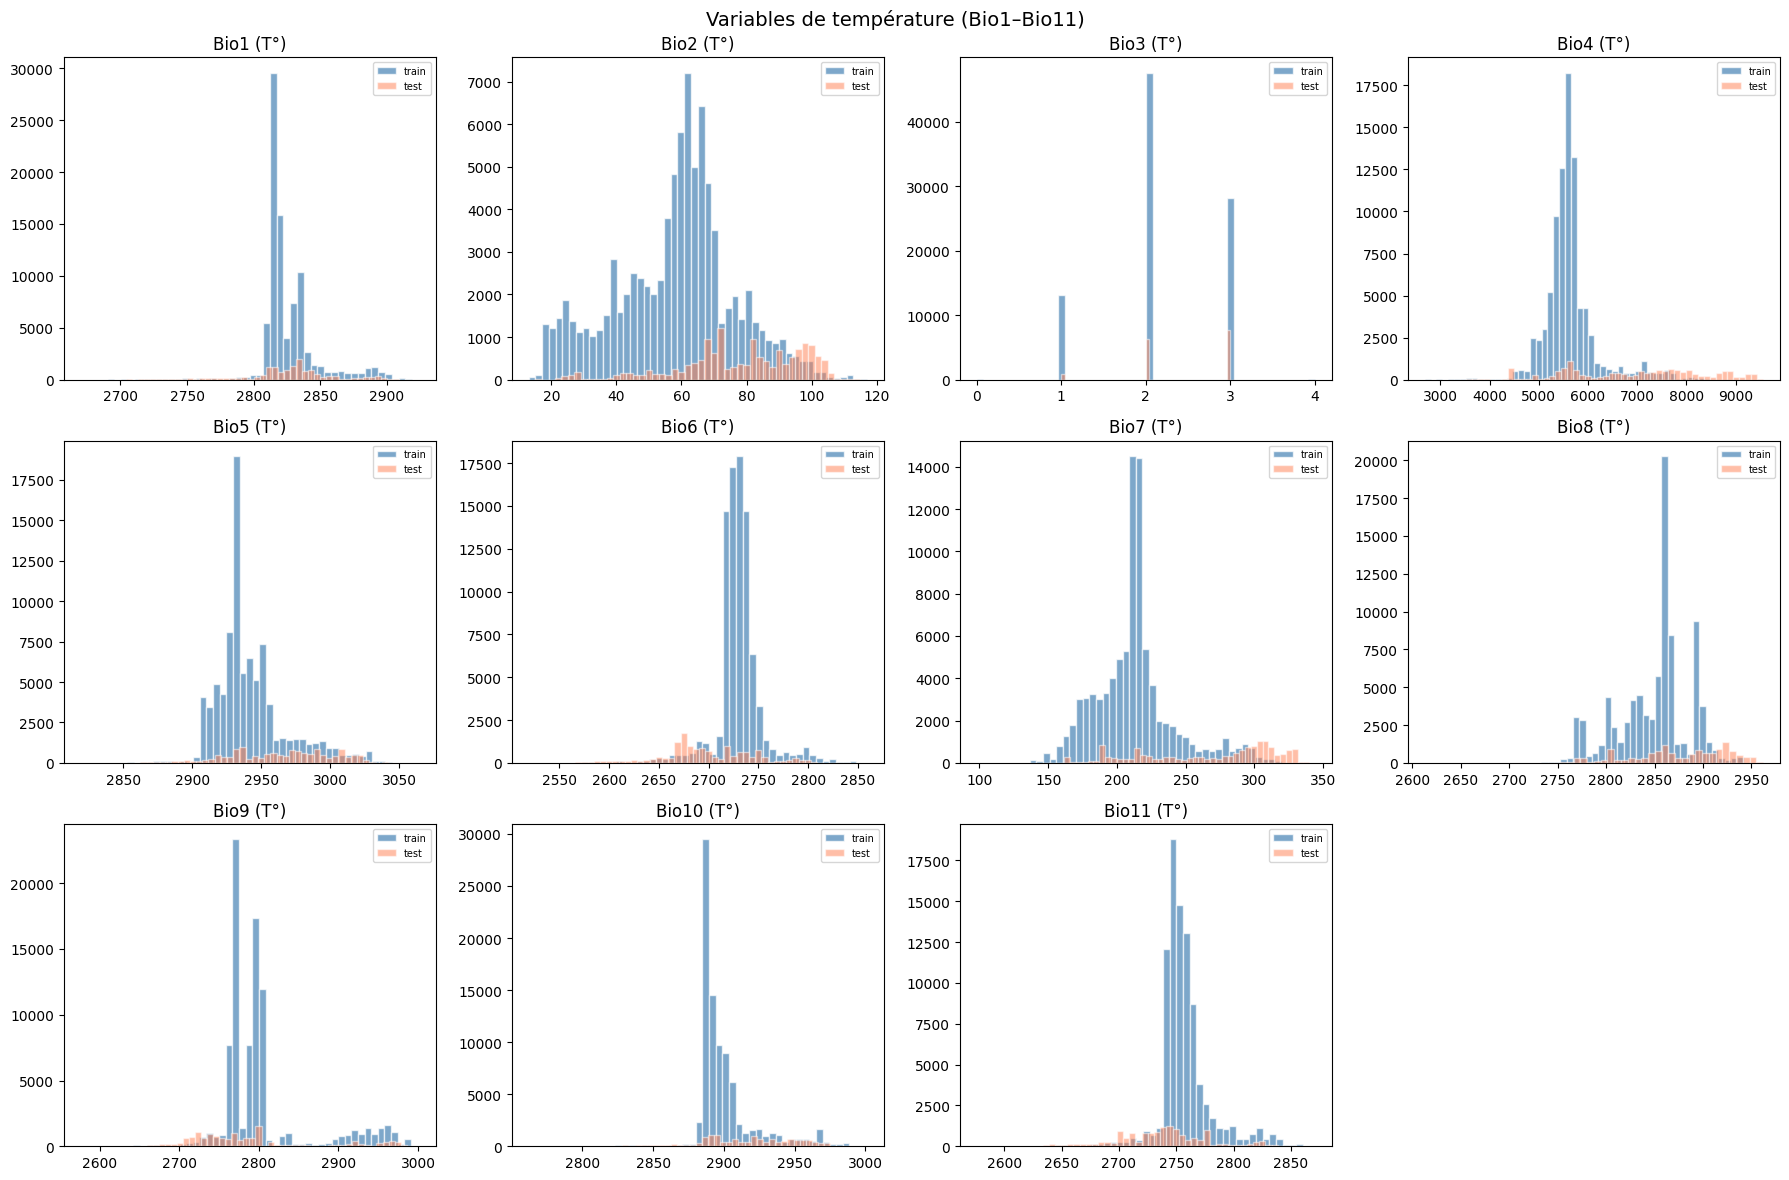

In [4]:
temp_cols  = ['Bio1','Bio2','Bio3','Bio4','Bio5','Bio6','Bio7','Bio8','Bio9','Bio10','Bio11']
precip_cols = ['Bio12','Bio13','Bio14','Bio15','Bio16','Bio17','Bio18','Bio19']

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(temp_cols):
    axes[i].hist(train[col].dropna(), bins=50, color='steelblue', alpha=0.7, label='train', edgecolor='white')
    axes[i].hist(test[col].dropna(), bins=50, color='coral', alpha=0.5, label='test', edgecolor='white')
    axes[i].set_title(col + ' (T°)')
    axes[i].legend(fontsize=7)

for j in range(len(temp_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Variables de température (Bio1–Bio11)', fontsize=14)
plt.tight_layout()
plt.show()

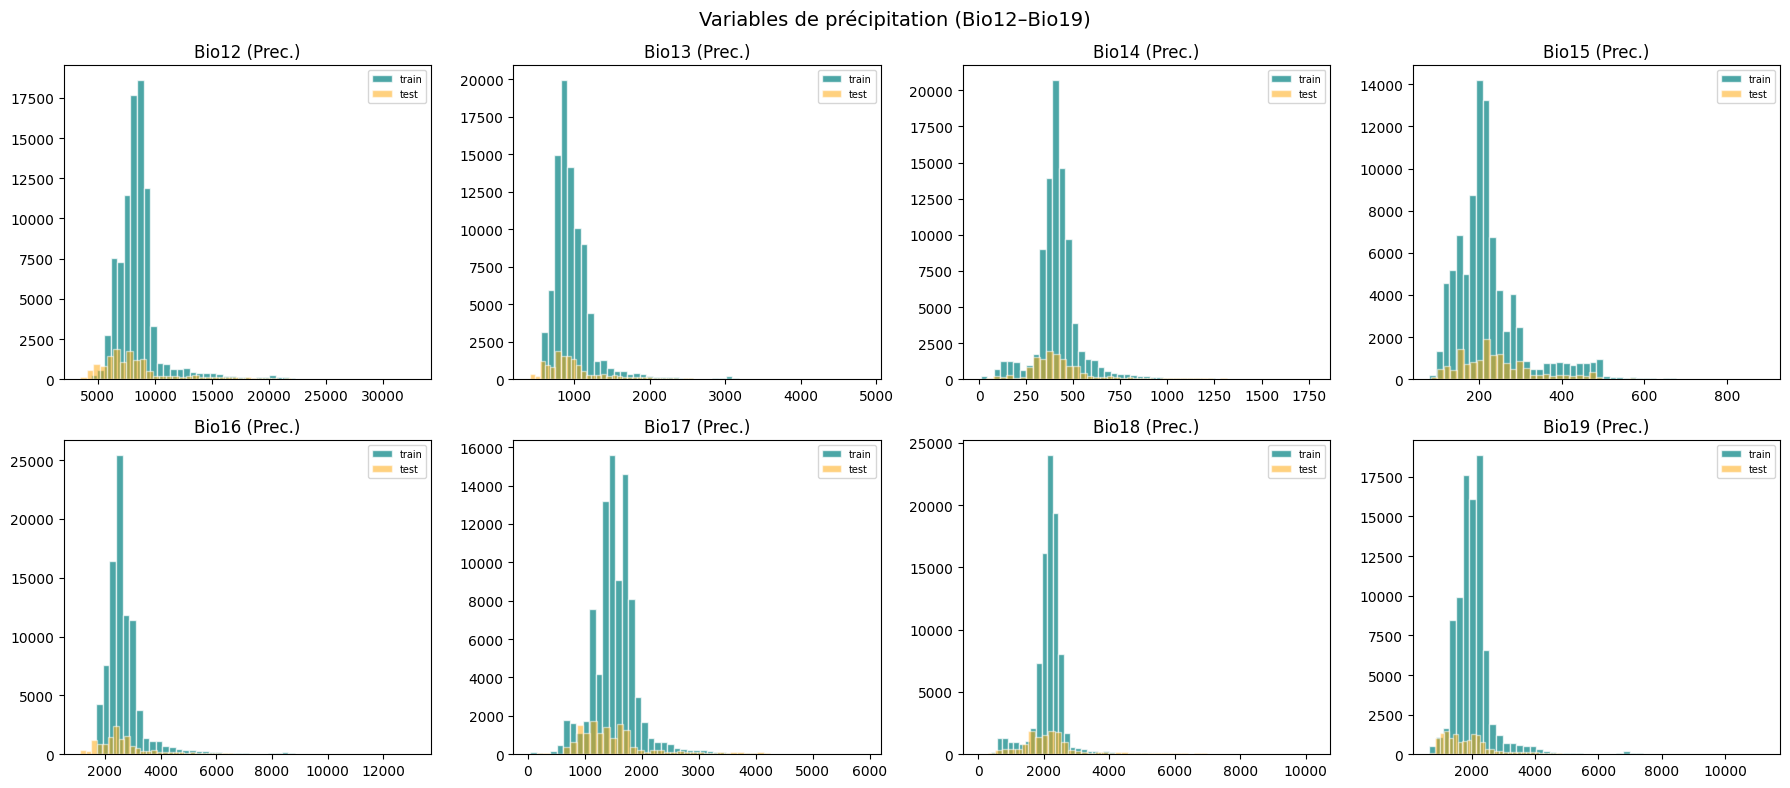

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(precip_cols):
    axes[i].hist(train[col].dropna(), bins=50, color='teal', alpha=0.7, label='train', edgecolor='white')
    axes[i].hist(test[col].dropna(), bins=50, color='orange', alpha=0.5, label='test', edgecolor='white')
    axes[i].set_title(col + ' (Prec.)')
    axes[i].legend(fontsize=7)

plt.suptitle('Variables de précipitation (Bio12–Bio19)', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Matrice de corrélation

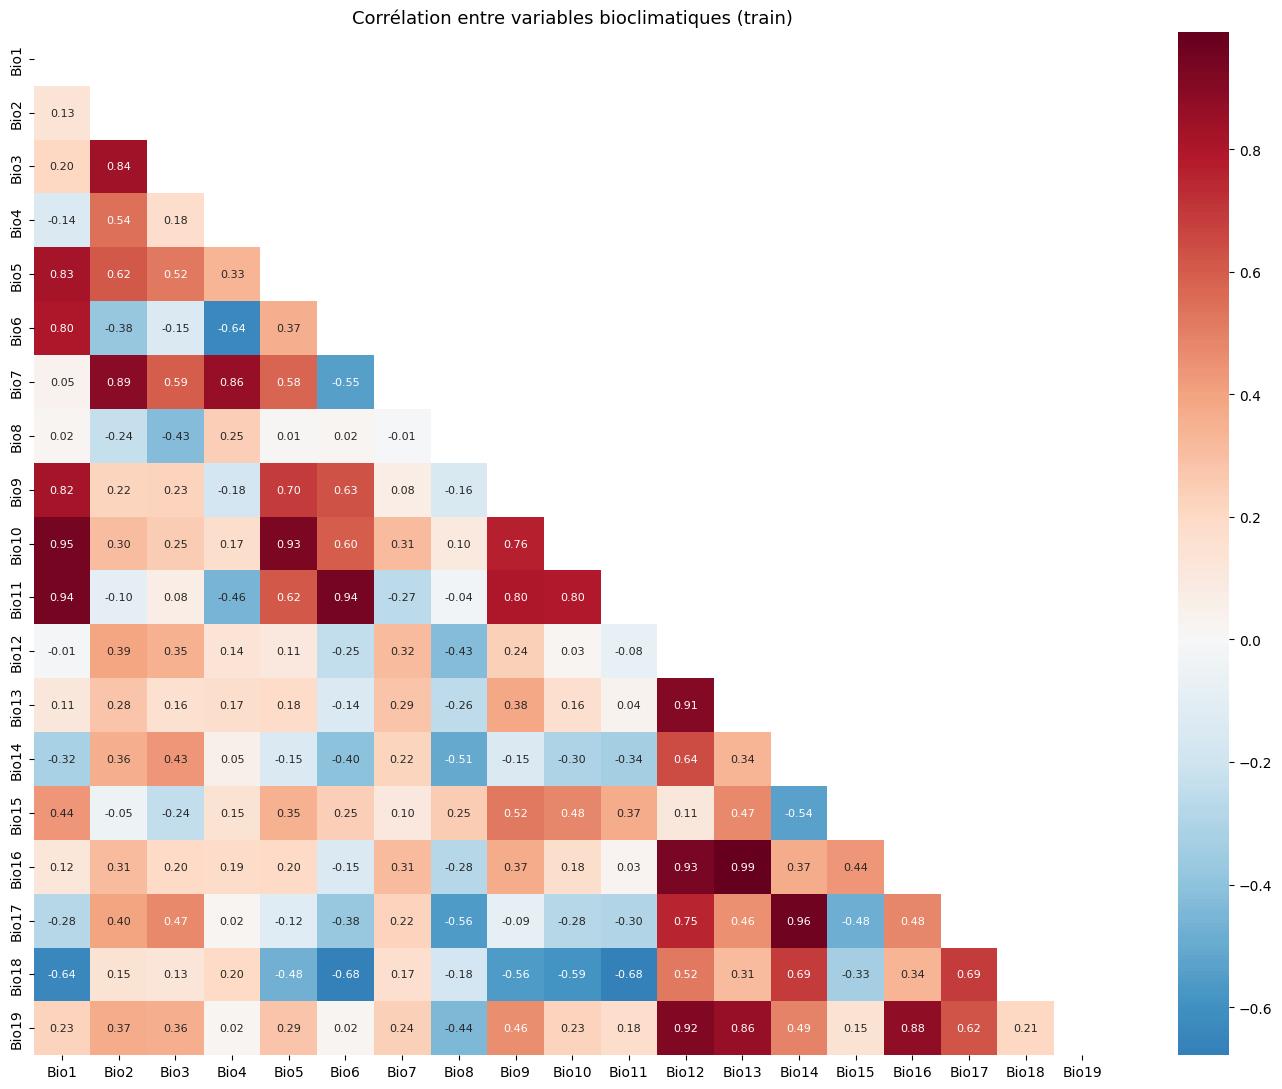

In [6]:
fig, ax = plt.subplots(figsize=(14, 11))
corr = train[bio_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=mask, ax=ax, annot_kws={'size': 8})
ax.set_title('Corrélation entre variables bioclimatiques (train)', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Espace climatique (Bio1 vs Bio12)

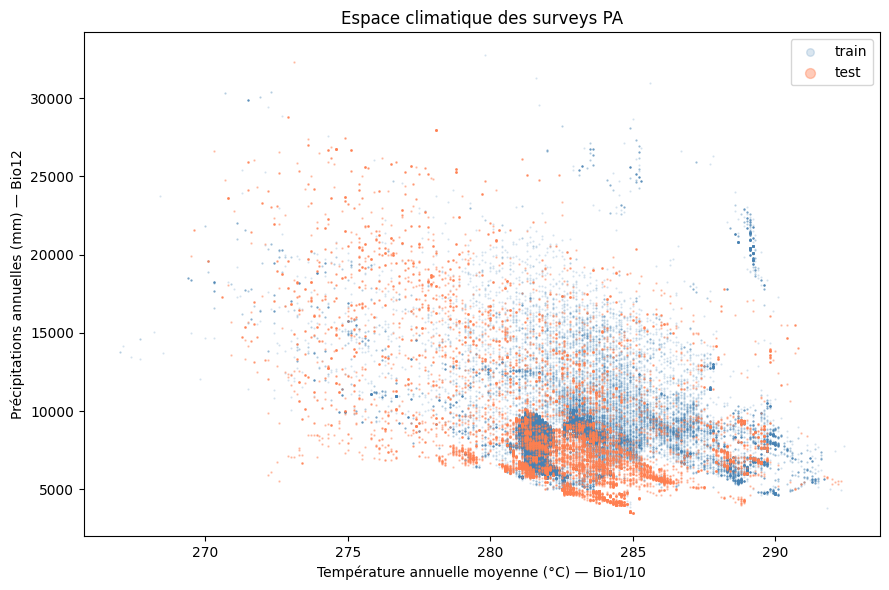

In [7]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(train['Bio1'] / 10, train['Bio12'], s=0.3, alpha=0.2, c='steelblue', label='train')
ax.scatter(test['Bio1'] / 10, test['Bio12'], s=0.5, alpha=0.4, c='coral', label='test')
ax.set_xlabel('Température annuelle moyenne (°C) — Bio1/10')
ax.set_ylabel('Précipitations annuelles (mm) — Bio12')
ax.set_title('Espace climatique des surveys PA')
ax.legend(markerscale=10)
plt.tight_layout()
plt.show()